# Feature Engineering Analysis
Sprint 2 — Shotgun Demand Forecasting

This notebook documents and analyzes the 42+ engineered features built in Sprint 2.
It covers feature inventory, distributions, correlations, collinearity, target
analysis, and rationale for each of the 10 feature groups.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Project root (one level up from notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Plotting defaults (match notebook 01 conventions)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

# Load feature data from Parquet
df = pd.read_parquet(PROJECT_ROOT / "data" / "features")
print(f"Feature DataFrame shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Feature DataFrame shape: (4440, 54)
Columns (54): ['subcategory', 'sizing', 'tactical', 'date', 'quantity', 'amount', 'barrel_length', 'transaction_count', 'avg_price', 'month', 'quarter', 'year', 'month_sin', 'month_cos', 'covid_period', 'post_covid', 'is_march', 'off_season', 'months_to_hunting', 'is_waterfowl_season', 'is_upland_season', 'is_turkey_spring_season', 'is_turkey_fall_season', 'is_dove_season', 'is_deer_season', 'hunting_intensity', 'quantity_lag_1', 'quantity_lag_3', 'quantity_lag_6', 'quantity_lag_12', 'avg_price_lag_1', 'quantity_yoy_change', 'quantity_mom_change', 'quantity_ma_3', 'quantity_std_3', 'quantity_ma_6', 'quantity_std_6', 'quantity_ma_12', 'quantity_std_12', 'sizing_grouped', 'is_tactical', 'is_tactical_na', 'is_semiautomatic', 'is_single_shot', 'is_over_under', 'is_lever_action', 'is_side_by_side', 'is_bolt_action', 'is_rifle_shotgun', 'is_revolver', 'is_12ga', 'subcat_total_qty', 'subcat_share', 'time_index']
Date range: 2019-01-01 to 2023-12-01


---
## 1. Feature Inventory

Complete listing of all engineered features with their group assignment, data type,
non-null count, and unique values (for low-cardinality columns).

In [2]:
# Define feature group assignments
FEATURE_GROUPS = {
    # Time features
    "month": "time", "quarter": "time", "year": "time",
    "month_sin": "time", "month_cos": "time",
    # Hunting season flags
    "is_waterfowl_season": "hunting_season", "is_upland_season": "hunting_season",
    "is_turkey_spring_season": "hunting_season", "is_turkey_fall_season": "hunting_season",
    "is_dove_season": "hunting_season", "is_deer_season": "hunting_season",
    "hunting_intensity": "hunting_season",
    # Domain events
    "covid_period": "domain_event", "post_covid": "domain_event",
    "is_march": "domain_event", "off_season": "domain_event",
    "months_to_hunting": "domain_event",
    # Lag features
    "quantity_lag_1": "lag", "quantity_lag_3": "lag",
    "quantity_lag_6": "lag", "quantity_lag_12": "lag",
    # Rolling stats
    "quantity_ma_3": "rolling", "quantity_ma_6": "rolling",
    "quantity_ma_12": "rolling", "quantity_std_3": "rolling",
    "quantity_std_6": "rolling", "quantity_std_12": "rolling",
    # Derived lag features
    "quantity_yoy_change": "derived_lag", "quantity_mom_change": "derived_lag",
    # Price features
    "avg_price": "price", "avg_price_lag_1": "price",
    # Product encodings
    "sizing_grouped": "product_encoding", "is_tactical": "product_encoding",
    "is_tactical_na": "product_encoding", "is_12ga": "product_encoding",
    # Cross-product
    "subcat_total_qty": "cross_product", "subcat_share": "cross_product",
    # Structural
    "time_index": "structural",
    # Identifiers (not features)
    "subcategory": "identifier", "sizing": "identifier", "tactical": "identifier",
    "date": "identifier", "quantity": "target", "amount": "identifier",
    "barrel_length": "identifier", "transaction_count": "identifier",
}

# Build inventory table
inventory = []
for col in df.columns:
    group = FEATURE_GROUPS.get(col, "product_encoding")  # subcategory one-hot dummies
    non_null = df[col].notna().sum()
    unique = df[col].nunique()
    inventory.append({
        "feature": col,
        "group": group,
        "dtype": str(df[col].dtype),
        "non_null": non_null,
        "null": len(df) - non_null,
        "unique": unique,
    })

inv_df = pd.DataFrame(inventory)

# Display grouped summary
print(f"Total columns: {len(df.columns)}")
print(f"\nFeature groups:")
group_counts = inv_df[~inv_df["group"].isin(["identifier", "target"])].groupby("group").size()
for g, c in group_counts.sort_values(ascending=False).items():
    print(f"  {g:20s} {c:3d} features")
print(f"  {'TOTAL':20s} {group_counts.sum():3d} features")

# Show full inventory
inv_df.style.set_caption("Feature Inventory")

Total columns: 54

Feature groups:


  product_encoding      12 features
  hunting_season         7 features
  rolling                6 features
  domain_event           5 features
  time                   5 features
  lag                    4 features
  cross_product          2 features
  derived_lag            2 features
  price                  2 features
  structural             1 features
  TOTAL                 46 features


,feature,group,dtype,non_null,null,unique
0,subcategory,identifier,str,4440,0,9
1,sizing,identifier,str,4440,0,14
2,tactical,identifier,str,4440,0,3
3,date,identifier,object,4440,0,60
4,quantity,target,int64,4440,0,1244
5,amount,identifier,float64,4440,0,2702
6,barrel_length,identifier,float64,4440,0,232
7,transaction_count,identifier,int64,4440,0,20
8,avg_price,price,float64,4440,0,2607
9,month,time,int32,4440,0,12


---
## 2. Distribution Analysis

Histograms for key features across the major feature groups.

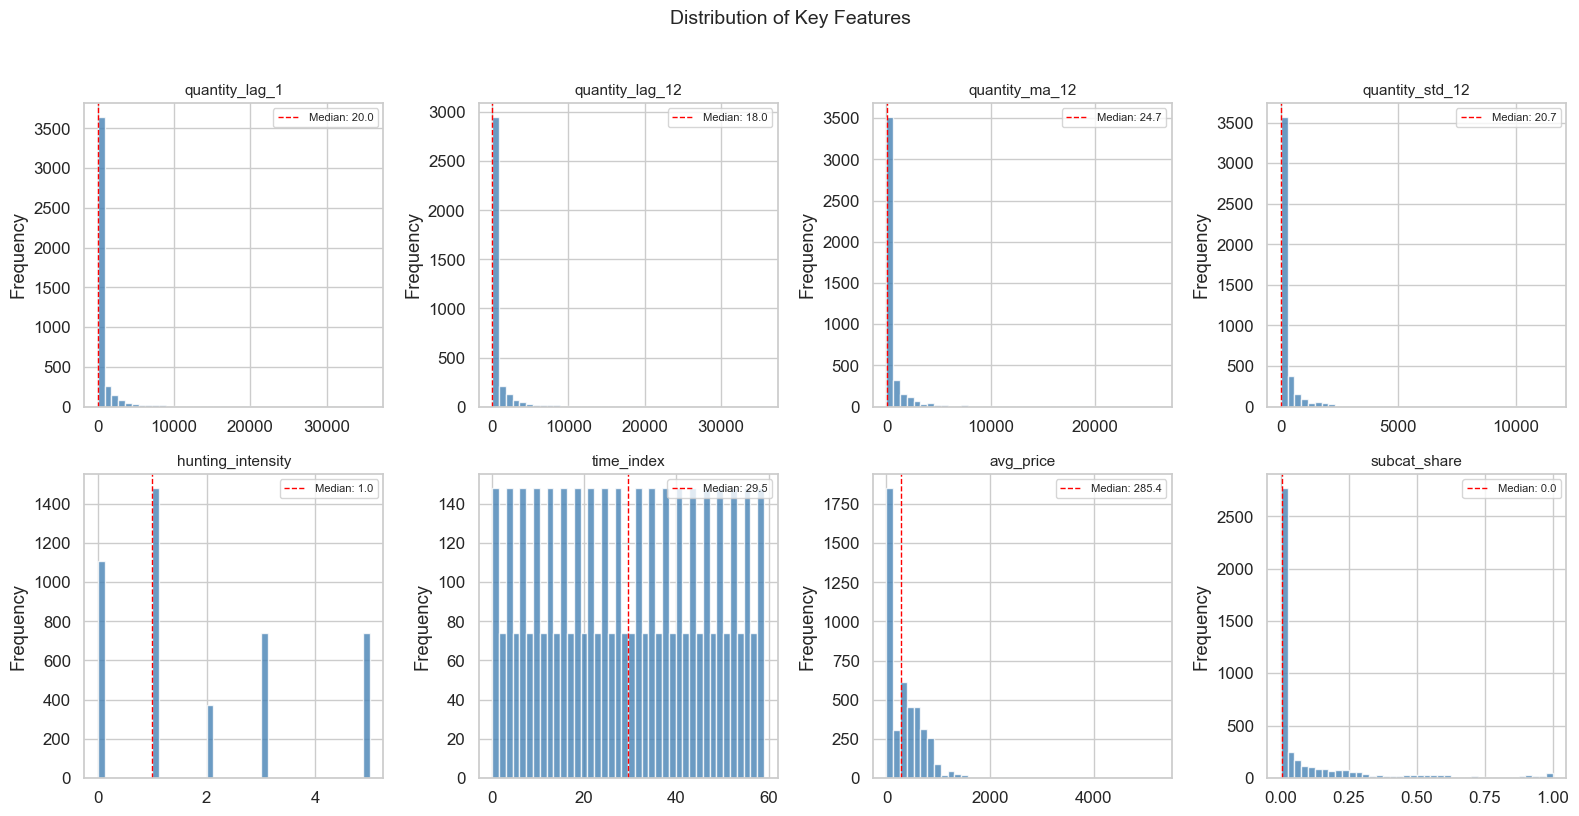

In [3]:
# Key features to visualize across different groups
key_features = [
    "quantity_lag_1", "quantity_lag_12", "quantity_ma_12", "quantity_std_12",
    "hunting_intensity", "time_index", "avg_price", "subcat_share",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    data = df[feat].dropna()
    ax.hist(data, bins=40, edgecolor="white", alpha=0.8, color="steelblue")
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel("Frequency")
    # Add median line
    med = data.median()
    ax.axvline(med, color="red", linestyle="--", linewidth=1,
               label=f"Median: {med:.1f}")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Key Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Correlation Matrix

Full heatmap of numeric feature correlations. With 40+ features, annotations are
omitted for readability — use the collinearity check in Section 5 for specific pairs.

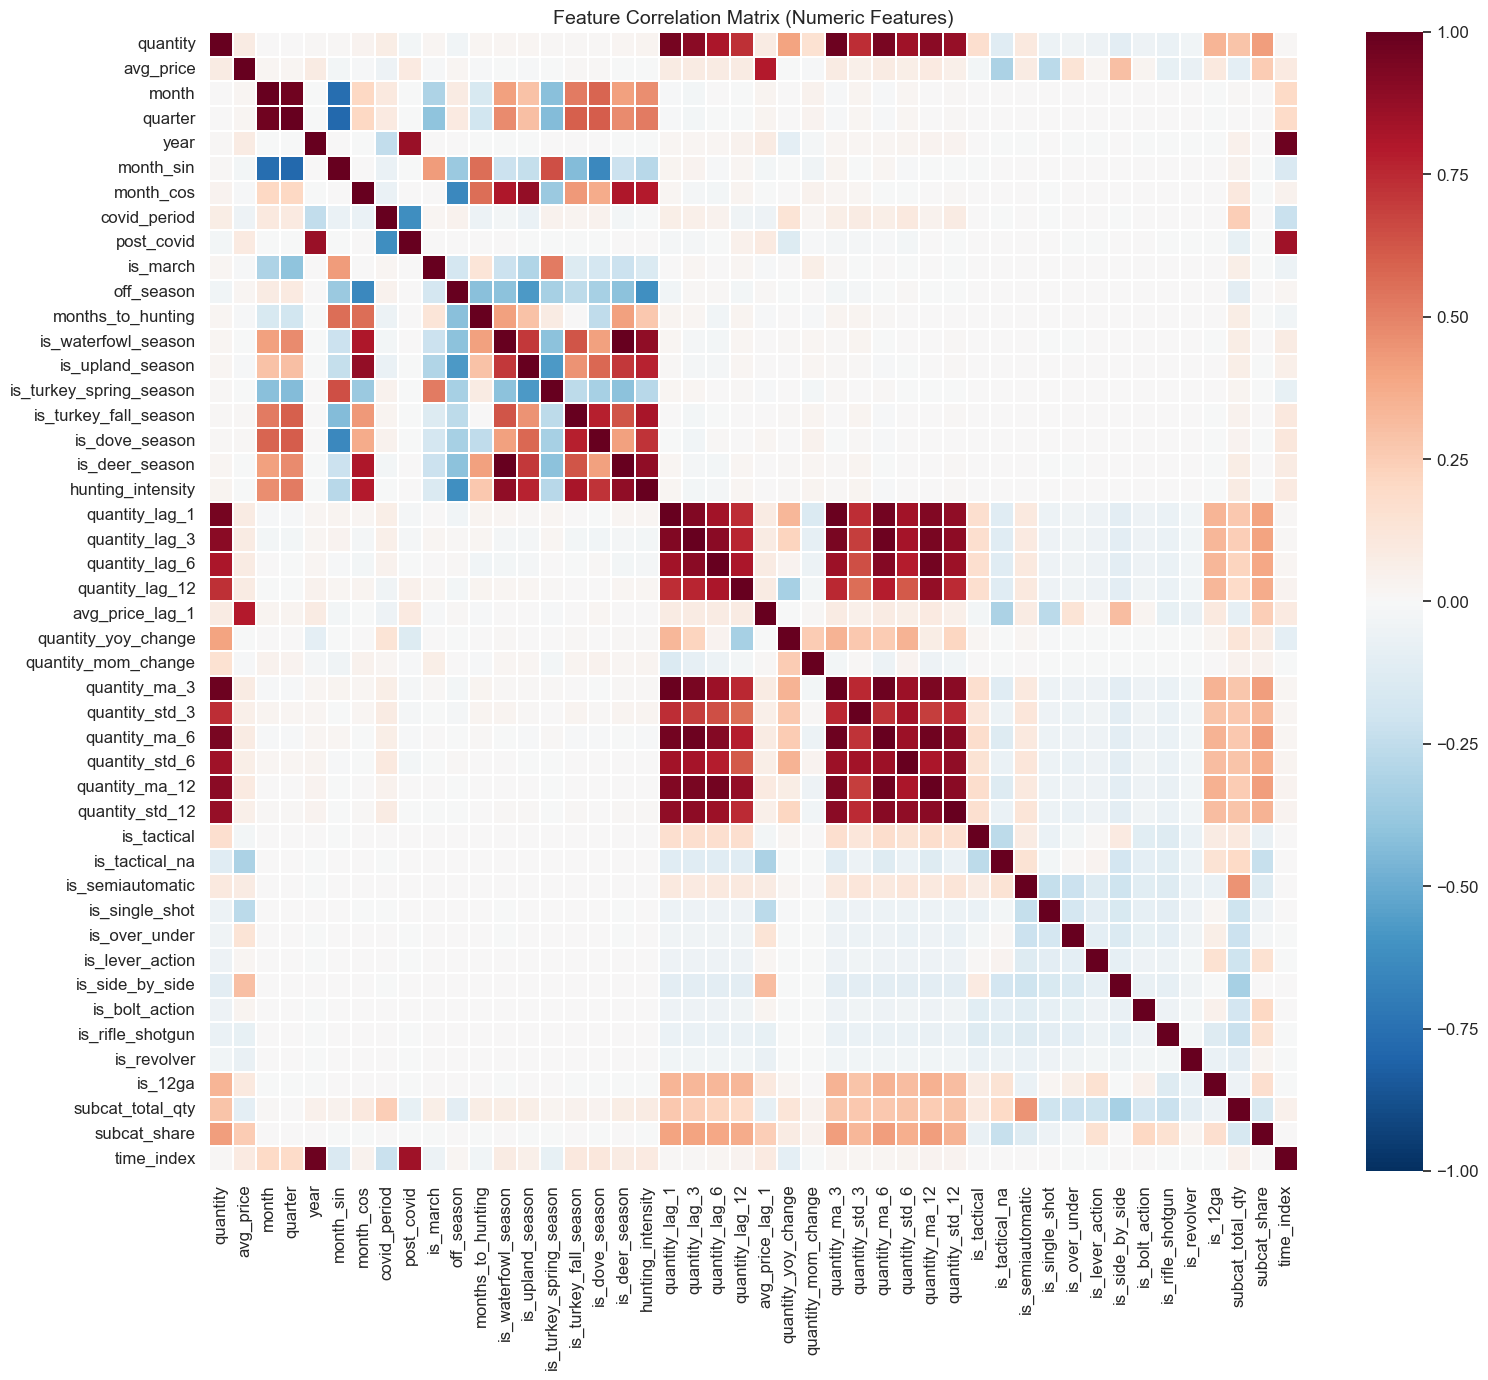

Correlation matrix: 46 x 46 features


In [4]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove identifier columns that happen to be numeric
exclude = {"amount", "barrel_length", "transaction_count"}
feature_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.2,
    ax=ax,
)
ax.set_title("Feature Correlation Matrix (Numeric Features)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Correlation matrix: {corr_matrix.shape[0]} x {corr_matrix.shape[1]} features")

---
## 4. Feature Group Rationale

Documentation of why each feature group was chosen, based on domain research
and ML best practices. See `specs/research/sprint2-feature-engineering-research.md`
for full citations and sources.

### Group 1: Time Features (5 features)
`month`, `quarter`, `year`, `month_sin`, `month_cos`

- **Integer `month` (1–12)**: Primary temporal feature for tree-based models (XGBoost/LightGBM). Trees split directly on month boundaries, making this more effective than cyclical encoding for gradient boosting.
- **`month_sin` / `month_cos`**: Cyclical encoding so December (12) and January (1) are numerically close. Included for Ridge/SARIMA linear baselines where cyclical continuity matters. Harmless for tree models — they simply ignore these if unhelpful.
- **`quarter` (1–4)**: Coarser seasonal grouping. Helps trees capture broad seasonal patterns with fewer splits.
- **`year` (2019–2023)**: Captures the 5-year trend trajectory, including COVID-era structural shifts.

### Group 2: Hunting Season Flags (7 features)
`is_waterfowl_season`, `is_upland_season`, `is_turkey_spring_season`, `is_turkey_fall_season`, `is_dove_season`, `is_deer_season`, `hunting_intensity`

- **6 US shotgun-relevant seasons**: Based on national hunting calendar research across state wildlife agencies. Each flag is binary (1 = active month, 0 = inactive).
- **Dove season (Sep–Nov)**: Added because dove is the first fall hunting opener and is exclusively a shotgun season. Kicks off the fall buying cycle.
- **Deer season (Oct–Jan)**: Added because 10 US states mandate shotgun-only for deer hunting (OH, IA, IL, IN, MD, NJ, MA, DE, ME, RI). Slug guns are typically pump-action/semiauto 12 GA — products in the DLX data.
- **Wrap-around handling**: Waterfowl (Oct–Jan) and deer (Oct–Jan) cross the year boundary. Implementation uses OR logic: `month >= start OR month <= end`.
- **`hunting_intensity`**: Composite score = sum of all 6 season flags (0–6). Captures the cumulative effect of overlapping seasons.

### Group 3: Domain Event Features (5 features)
`covid_period`, `post_covid`, `is_march`, `off_season`, `months_to_hunting`

- **`covid_period` (Mar 2020 – Dec 2021)**: The largest structural break in the dataset. The old project measured a +105% demand surge during this period. Essential for the model to separate pandemic-era demand from normal patterns.
- **`post_covid` (2022+)**: Captures the normalization period after the surge. Demand levels in 2022–2023 are lower than the 2020–2021 peak but may not fully return to pre-COVID baseline.
- **`is_march`**: The strongest seasonal peak in the data (seasonal index 123.3). Driven by tax refund spending and dealer pre-season stocking for fall. Warranted as a standalone binary feature because March consistently outperforms adjacent months.
- **`off_season` (Jun–Aug)**: Summer trough when hunting activity is minimal. July has the lowest seasonal index (73.6). Grouping the 3-month trough into one flag avoids redundancy with the integer month feature.
- **`months_to_hunting`**: Distance to the October hunting-season opener: `(22 - month) % 12`. Provides a continuous countdown that models can learn buying-anticipation patterns from.

### Group 4: Lag Features (4 features)
`quantity_lag_1`, `quantity_lag_3`, `quantity_lag_6`, `quantity_lag_12`

- **Lag 1**: Short-term momentum/autocorrelation. Most recent observation.
- **Lag 3**: Quarterly pattern — captures seasonality at the quarter level.
- **Lag 6**: Semi-annual pattern — bridges between quarterly and annual.
- **Lag 12**: Year-over-year seasonal comparison. Often the single most important lag for monthly seasonal data.
- **Partitioned by product**: Uses PySpark Window partitioned by `(subcategory, sizing, tactical)` to prevent data leakage between products.
- **Warm-up cost**: Lag 12 means the first 12 months per product are lost to NaN, reducing effective training from 4,440 to ~3,552 rows.

### Group 5: Rolling Statistics (6 features)
`quantity_ma_3`, `quantity_ma_6`, `quantity_ma_12`, `quantity_std_3`, `quantity_std_6`, `quantity_std_12`

- **Rolling mean (MA)**: Smoothed demand level at 3/6/12-month horizons. Captures short, medium, and long-term trend.
- **Rolling standard deviation**: Demand volatility at each horizon. High-volatility products behave differently from stable ones.
- **Backwards-looking only**: Uses `rowsBetween(-(w-1), 0)` — no future data leakage.
- **Min_periods guard**: `stddev` is only computed when the window contains ≥2 rows (avoids undefined single-observation variance).
- **Skipped min/max**: Limits rolling features to mean and std to control total feature count (~40 budget).

### Group 6: Derived Lag Features (2 features)
`quantity_yoy_change`, `quantity_mom_change`

- **`quantity_yoy_change`**: `quantity - quantity_lag_12`. Year-over-year absolute change captures direction and magnitude of annual demand shifts. Critical for detecting whether a product is growing or declining.
- **`quantity_mom_change`**: `quantity - quantity_lag_1`. Month-over-month absolute change captures short-term momentum direction.
- **Absolute differences over percentages**: Percentage changes are avoided because zero-filled data creates division-by-zero issues (37.4% of rows have quantity = 0).

### Group 7: Price Features (2 features)
`avg_price`, `avg_price_lag_1`

- **`avg_price`**: Current period average unit price (amount / quantity). Captures the product's price point, which differs substantially across subcategories and gauges.
- **`avg_price_lag_1`**: Prior period price. Allows the model to detect price change effects — a price increase in the prior month may suppress current demand.
- **Amount lags skipped**: Dollar amount lags are highly correlated with quantity lags (price × quantity). Including both adds redundancy without new information.

### Group 8: Product Encodings (~10 features)
`sizing_grouped`, `is_tactical`, `is_tactical_na`, `is_12ga`, + subcategory one-hot dummies

- **Rare gauge grouping**: Reduces gauge cardinality from 14 to ~7 by mapping gauges outside the top 6 (12 GA, 20 GA, .410, 28 GA, 16 GA, 45/410) to `OTHER_GAUGE`. Prevents sparse categorical features from overfitting.
- **`is_tactical` / `is_tactical_na`**: Two binary flags capture the 3-level tactical column (Y/N/NA). The "NA" string is a valid third category (764 original rows, growing over time), NOT missing data.
- **Subcategory one-hot**: One-hot encoding with the most common subcategory dropped as reference. Tree models can use these to learn subcategory-specific patterns.
- **`is_12ga`**: Convenience flag for the dominant gauge (12 GA represents the majority of shotgun volume).

### Group 9: Cross-Product Features (2 features)
`subcat_total_qty`, `subcat_share`

- **`subcat_total_qty`**: Total quantity across all products in the same subcategory for the same month. Captures "is the overall pump-action (or semiauto, etc.) market up or down?" — category-level demand signal.
- **`subcat_share`**: Product's quantity / subcategory total. Captures relative market position — is this product gaining or losing share within its category?
- **Research basis**: Huang et al. (2016, European Journal of Operational Research) found that intra-category information accounts for 95% of forecasting improvements from cross-product features. Inter-category effects contribute only 5%.

### Group 10: Structural Feature (1 feature)
`time_index`

- **Per-product linear time index (0–59)**: Captures product-specific linear trend. Computed via `row_number() - 1` over the product-partitioned window.
- **Why per-product**: A global time index incorrectly assumes all products start at the same time point. The per-product version correctly captures each product's own trajectory.
- **Old project fix**: The old v2 project used `np.arange(len(df))` — a global index that is meaningless in a panel dataset. This version uses PySpark `F.row_number()` partitioned by product.

---
## 5. Collinearity Check

Identify highly correlated feature pairs (|r| > 0.9) and classify them as
expected (by design) vs. concerning (potentially redundant).

In [5]:
# Find feature pairs with |correlation| > 0.9
threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            high_corr_pairs.append({
                "feature_1": corr_matrix.columns[i],
                "feature_2": corr_matrix.columns[j],
                "correlation": round(r, 4),
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    "correlation", key=abs, ascending=False
)

# Classify as expected vs concerning
EXPECTED_PAIRS = {
    # Rolling features at nested windows are inherently correlated
    ("quantity_ma_3", "quantity_ma_6"),
    ("quantity_ma_3", "quantity_ma_12"),
    ("quantity_ma_6", "quantity_ma_12"),
    ("quantity_std_3", "quantity_std_6"),
    ("quantity_std_3", "quantity_std_12"),
    ("quantity_std_6", "quantity_std_12"),
    # Lag 1 and MoM change share quantity_lag_1 component
    ("quantity_lag_1", "quantity_mom_change"),
    # Lag features at different horizons share recent history
    ("quantity_lag_1", "quantity_lag_3"),
    ("quantity_lag_1", "quantity_ma_3"),
    ("quantity_lag_3", "quantity_lag_6"),
    # Hunting seasons that overlap in calendar months
    ("is_waterfowl_season", "is_deer_season"),
    ("is_waterfowl_season", "is_turkey_fall_season"),
    ("is_deer_season", "is_turkey_fall_season"),
    ("is_dove_season", "is_turkey_fall_season"),
    ("is_dove_season", "is_upland_season"),
    # Rolling MA correlated with lag features
    ("quantity_lag_1", "quantity_ma_6"),
    ("quantity_lag_1", "quantity_ma_12"),
    # Price and lagged price
    ("avg_price", "avg_price_lag_1"),
}

def classify_pair(row):
    pair = (row["feature_1"], row["feature_2"])
    pair_rev = (row["feature_2"], row["feature_1"])
    if pair in EXPECTED_PAIRS or pair_rev in EXPECTED_PAIRS:
        return "Expected"
    return "Review"

if len(high_corr_df) > 0:
    high_corr_df["classification"] = high_corr_df.apply(classify_pair, axis=1)
    print(f"Feature pairs with |correlation| > {threshold}: {len(high_corr_df)}")
    print(f"  Expected (by design): {(high_corr_df['classification'] == 'Expected').sum()}")
    print(f"  Review needed:        {(high_corr_df['classification'] == 'Review').sum()}")
    print()
    display(high_corr_df)
else:
    print(f"No feature pairs with |correlation| > {threshold}")

Feature pairs with |correlation| > 0.9: 23
  Expected (by design): 9
  Review needed:        14



,feature_1,feature_2,correlation,classification
7,is_waterfowl_season,is_deer_season,1.0000,Expected
9,quantity_lag_1,quantity_ma_3,0.9883,Expected
18,quantity_ma_3,quantity_ma_6,0.9832,Expected
14,quantity_lag_3,quantity_ma_6,0.9805,Review
6,year,time_index,0.9799,Review
2,quantity,quantity_ma_3,0.9791,Review
20,quantity_ma_6,quantity_ma_12,0.9730,Expected
5,month,quarter,0.9716,Review
10,quantity_lag_1,quantity_ma_6,0.9683,Expected
17,quantity_lag_6,quantity_ma_12,0.9620,Review


---
## 6. Target Correlation Analysis

Correlation of each numeric feature with the `quantity` target variable,
ranked by absolute correlation strength.

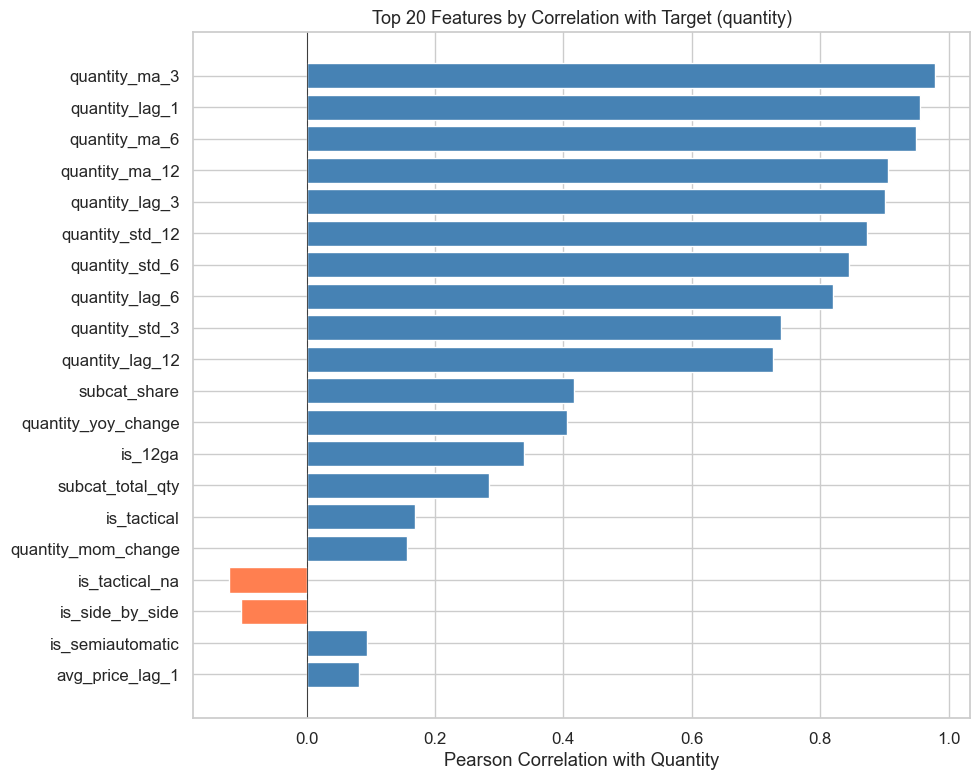

Full feature-target correlation ranking:


,feature,correlation_with_quantity
0,quantity_ma_3,0.979065
1,quantity_lag_1,0.955694
2,quantity_ma_6,0.949327
3,quantity_ma_12,0.906022
4,quantity_lag_3,0.900998
5,quantity_std_12,0.873679
6,quantity_std_6,0.844357
7,quantity_lag_6,0.820250
8,quantity_std_3,0.739134
9,quantity_lag_12,0.726624


In [6]:
# Compute correlation of each feature with quantity target
target = "quantity"
feature_only = [c for c in feature_cols if c != target]

target_corr = df[feature_only].corrwith(df[target]).dropna().sort_values(
    key=abs, ascending=False
)
target_corr_df = target_corr.reset_index()
target_corr_df.columns = ["feature", "correlation_with_quantity"]
target_corr_df["abs_correlation"] = target_corr_df["correlation_with_quantity"].abs()
target_corr_df = target_corr_df.sort_values("abs_correlation", ascending=False)

# Horizontal bar chart — top 20
top_n = min(20, len(target_corr_df))
top_features = target_corr_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["steelblue" if v >= 0 else "coral"
          for v in top_features["correlation_with_quantity"]]
ax.barh(
    range(top_n),
    top_features["correlation_with_quantity"].values,
    color=colors,
    edgecolor="white",
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Pearson Correlation with Quantity")
ax.set_title(f"Top {top_n} Features by Correlation with Target (quantity)", fontsize=13)
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

# Full table
print("Full feature-target correlation ranking:")
display(target_corr_df[["feature", "correlation_with_quantity"]].reset_index(drop=True))

---
## 7. Summary

Key metrics about the engineered feature set for Sprint 2.

In [7]:
# Summary statistics
identifier_cols = {"subcategory", "sizing", "tactical", "date", "amount",
                   "barrel_length", "transaction_count", "sizing_grouped"}
all_feature_cols = [c for c in df.columns if c not in identifier_cols and c != "quantity"]
n_features = len(all_feature_cols)

# Training rows after warm-up (drop rows where any lag column is NaN)
lag_cols = [c for c in df.columns if "_lag_" in c]
training_rows = df.dropna(subset=lag_cols).shape[0]

# Feature-to-observation ratio
ratio = n_features / training_rows

# High correlation pairs
n_high_corr = len(high_corr_df) if len(high_corr_df) > 0 else 0

# Top 5 features by target correlation
top5 = target_corr_df.head(5)

print("=" * 60)
print("SPRINT 2 FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"  Total feature columns:          {n_features}")
print(f"  Total rows (all products):      {len(df):,}")
print(f"  Training rows (after warm-up):  {training_rows:,}")
print(f"  Rows dropped (warm-up NaN):     {len(df) - training_rows:,}")
print(f"  Feature-to-observation ratio:   1:{training_rows // n_features}")
print(f"  Highly correlated pairs (>0.9): {n_high_corr}")
print()
print("  Top 5 features by |correlation| with quantity:")
for _, row in top5.iterrows():
    print(f"    {row['feature']:30s} r = {row['correlation_with_quantity']:+.4f}")
print()
print("  Feature group breakdown:")
for g, c in group_counts.sort_values(ascending=False).items():
    print(f"    {g:20s} {c:3d}")
print(f"    {'TOTAL':20s} {group_counts.sum():3d}")
print("=" * 60)

SPRINT 2 FEATURE ENGINEERING SUMMARY
  Total feature columns:          45
  Total rows (all products):      4,440
  Training rows (after warm-up):  3,552
  Rows dropped (warm-up NaN):     888
  Feature-to-observation ratio:   1:78
  Highly correlated pairs (>0.9): 23

  Top 5 features by |correlation| with quantity:
    quantity_ma_3                  r = +0.9791
    quantity_lag_1                 r = +0.9557
    quantity_ma_6                  r = +0.9493
    quantity_ma_12                 r = +0.9060
    quantity_lag_3                 r = +0.9010

  Feature group breakdown:
    product_encoding      12
    hunting_season         7
    rolling                6
    domain_event           5
    time                   5
    lag                    4
    cross_product          2
    derived_lag            2
    price                  2
    structural             1
    TOTAL                 46
